# 1

In [ ]:
#Подгружаем библиотеки и датасет
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sample_fraction = 0.3 #Если среда не позволяет обработать весь массив

print(f"Загрузка {sample_fraction*100}% данных...")
train_transaction = pd.read_csv('train_transaction.csv', skiprows=lambda i: i>0 and np.random.random() > sample_fraction)
train_identity = pd.read_csv('train_identity.csv')

print(f"Размер transaction: {train_transaction.shape}")
print(f"Размер identity: {train_identity.shape}")

Загрузка 30.0% данных...
Размер transaction: (176922, 394)
Размер identity: (144233, 41)


In [ ]:
#Объединяем части датасета и чистим
import gc
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

del train_transaction, train_identity
gc.collect()

0

Размер датасета: (176922, 434)


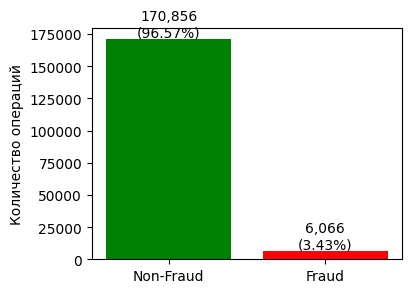

In [ ]:
print("Размер датасета:", df.shape)

plt.figure(figsize=(4, 3))
categories = ['Non-Fraud', 'Fraud']
counts = [len(df) - df['isFraud'].sum(), df['isFraud'].sum()]

bars = plt.bar(categories, counts, color=['green', 'red'])

for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{count:,.0f}\n({count/len(df)*100:.2f}%)', ha='center', va='bottom')

plt.ylabel('Количество операций')
plt.show()

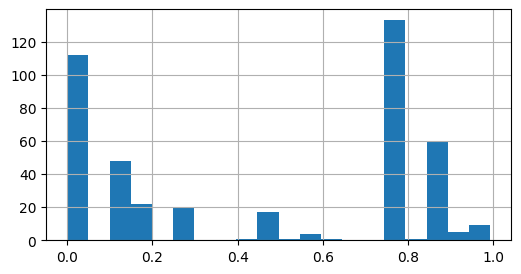

In [ ]:
#Процентрое соотношение пустых полей
missing_ratio = df.isnull().mean()

plt.figure(figsize=(6,3))
missing_ratio.hist(bins=20)
plt.show()

In [ ]:
#Удаляем пропуски и сторбец с id
df = df.drop(columns = missing_ratio[missing_ratio > 0.8].index)

print(f"Удалено столбцов: {len(missing_ratio[missing_ratio > 0.8].index)}. Где процент пропусков больше 80")

df = df.drop(columns=['TransactionID'])

Удалено столбцов: 74. Где процент пропусков больше 80


In [ ]:
#Удаляем почти константные признаки
quasi_constant_cols = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).values[0]
    if top_freq > 0.99:
        quasi_constant_cols.append(col)

df = df.drop(columns=quasi_constant_cols)

In [ ]:
df.shape

(176922, 344)

In [ ]:
#Выделяем столбец с меткой
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

y = df['isFraud']
X = df.drop(columns=['isFraud'])

#Делим признаки на котегореальные и дискретные
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

#Заполняем пропуски в обеих группах
for col in numeric_cols:
  X[col] = X[col].fillna(X[col].median())

label_encoders = {}
for col in categorical_cols:
    X[col] = X[col].fillna('Unknown')

    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

In [ ]:
#Делим на тест и трейн части
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train fraud rate: 0.03428785405936257
Test fraud rate: 0.034280062173237244


# 2

In [ ]:
#1 вариант стандартизации и масштабирования
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline

def create_pipeline():
    steps = []
    steps.append(('scaler', StandardScaler())) # Масштабирование
    steps.append(('smote', SMOTE(random_state=42))) # Балансировка
    steps.append(('classifier', LogisticRegression(random_state=42))) #Классификатор
    return ImbPipeline(steps)

print("Обучение базовой модели:\n")

pipeline = create_pipeline()

Обучение базовой модели:



In [ ]:
#2 вариант стандартизации и масштабирования
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [ ]:
# просто обучение или подбор гиперпараметров для метода
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

In [ ]:
# метрики
from sklearn.metrics import (classification_report, confusion_matrix,
                           roc_auc_score, roc_curve, average_precision_score,
                           precision_recall_curve, f1_score, precision_score, recall_score)
# average_precision_score - метрика для pr-auc
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_pred_proba)

In [ ]:
print("Результаты базовой модели:")
print(f"roc_auc: {roc_auc:.4f}")
print(f"f1: {f1:.4f}")
print(f"pr_auc: {pr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

Результаты базовой модели:
roc_auc: 0.8459
f1: 0.2061
pr_auc: 0.3975

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.82      0.89     34172
       Fraud       0.12      0.71      0.21      1213

    accuracy                           0.81     35385
   macro avg       0.55      0.76      0.55     35385
weighted avg       0.96      0.81      0.87     35385



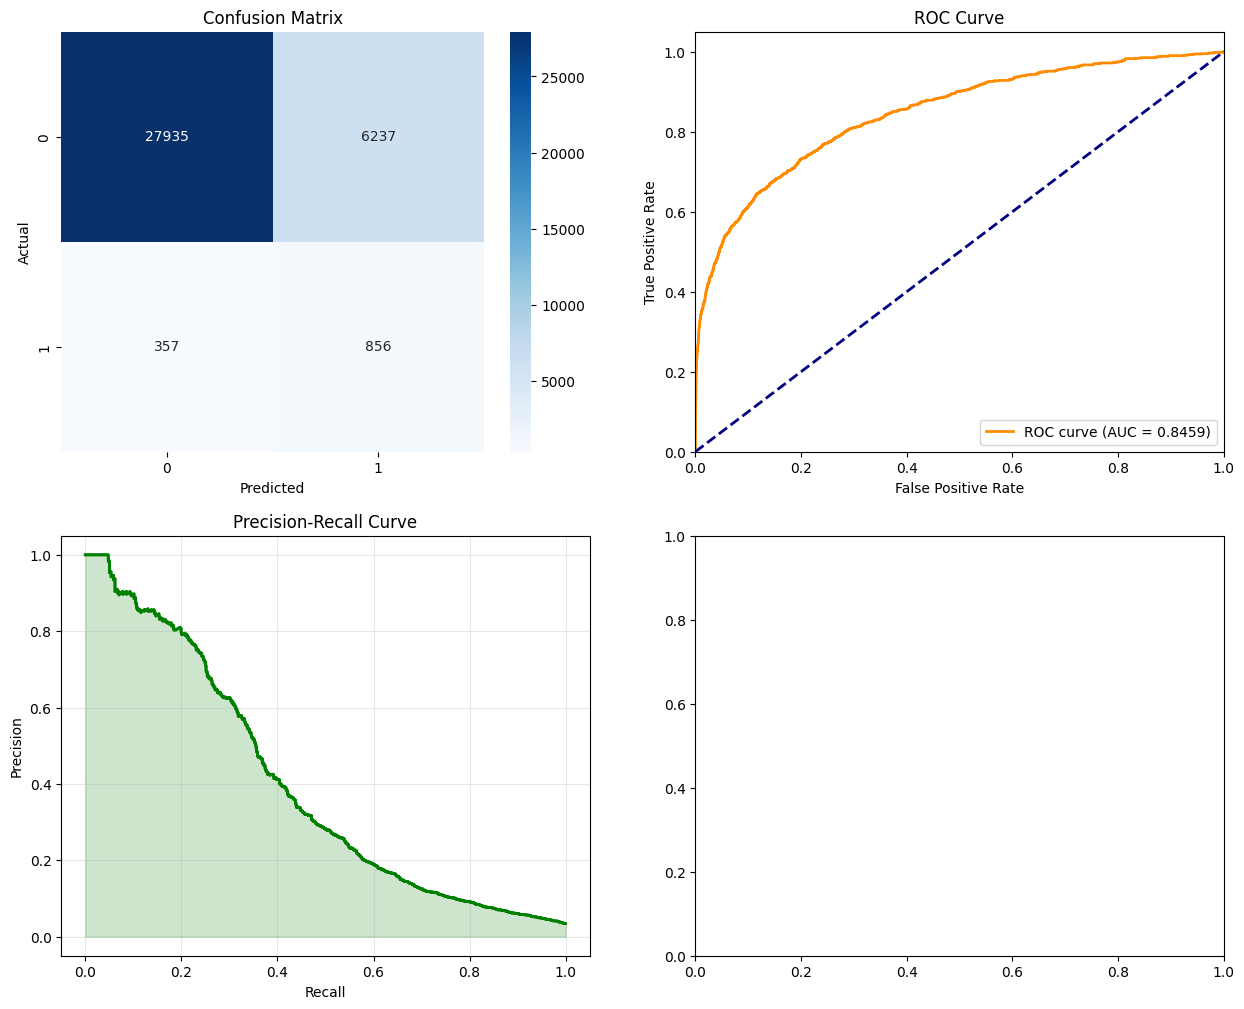

In [ ]:
import seaborn as sns
# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred) #y_pred - либо базового либо уже подобранного
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0,0], cmap='Blues')
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend(loc="lower right")

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1,0].plot(recall, precision, color='green', lw=2)
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve')
axes[1,0].grid(True, alpha=0.3)

axes[1,0].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[1,0].fill_between(recall, precision, alpha=0.2, color='green')